# 앙상블(Ensemble)

**여러 개의 머신러닝 모델을 이용해 최적의 답을 찾아내는 기법**

> 단일 모델 하나보다, 여러 모델을 조합했을 때 더 좋은 예측 성능을 낼 수 있다는 아이디어에서 출발합니다.  

**앙상블 기법의 종류**

| 기법 | 핵심 아이디어 | 대표 알고리즘 |
|------|-------------|-------------|
| 보팅 (Voting) | 다양한 모델의 예측 결과를 투표로 결합 | VotingClassifier |
| 배깅 (Bagging) | 데이터 샘플을 다르게 해 같은 모델 여러 개 학습 | RandomForest |
| 부스팅 (Boosting) | 이전 모델의 오차를 다음 모델이 보완 (순차 학습) | XGBoost, LightGBM, CatBoost |
| 스태킹 (Stacking) | 모델들의 예측값을 입력으로 삼아 메타 모델(최종 모델)이 최종 예측 | StackingClassifier |


### 분석에 필요한 패키지 Import

In [ ]:
# 다음 코드의 주석을 해제하고 패키지 설치
# !pip install xgboost lightgbm catboost scikit-learn --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')  # 불필요한 경고 메시지 숨기기

SEED = 42 # 재현성을 위한 난수 고정값 (어떤 숫자든 상관없음, 실행마다 동일 결과 보장)

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold  # 데이터 분할 및 교차 검증
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder  # 전처리
from sklearn.metrics import accuracy_score, classification_report             # 성능 평가 지표

# 기본 분류 모델 (앙상블과 성능 비교용)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 앙상블 모델
from sklearn.ensemble import (
    VotingClassifier,           # 보팅: 여러 모델의 예측을 투표로 결합
    BaggingClassifier,          # 배깅: 데이터 샘플링으로 여러 모델 생성
    RandomForestClassifier,     # 랜덤 포레스트: 배깅 + 특성 랜덤 선택
    AdaBoostClassifier,         # 에이다부스트: 오분류 샘플에 가중치 부여
    GradientBoostingClassifier, # 그래디언트 부스팅: 잔차를 순차적으로 학습
    StackingClassifier          # 스태킹: 모델 예측값을 메타 모델의 입력으로 사용
)

# 외부 부스팅 라이브러리
import xgboost as xgb                     # XGBoost: GBM의 속도 및 성능 개선 버전
import lightgbm as lgb                    # LightGBM: 리프 단위 분기로 매우 빠름
from catboost import CatBoostClassifier   # CatBoost: 범주형 변수 자동 처리 특화

맥북에서 XGBoostError 에러 뜨면 터미널에 아래 코드 입력하기!
> brew install libomp

### 데이터 로드

In [ ]:
# Employee.csv: 직원 정보 데이터셋
# 목표: 직원이 회사를 떠날지(LeaveOrNot) 예측하는 이진 분류 문제
df = pd.********('Employee.csv')

In [4]:
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [5]:
# 예측 대상(타겟) 컬럼 지정
# LeaveOrNot: 1이면 퇴직, 0이면 재직
target = 'LeaveOrNot'

In [ ]:
# 피처(X)와 타겟(y) 분리
# X: 모델 학습에 사용할 입력 변수들
# y: 모델이 맞춰야 할 정답 레이블
X = df.****(columns=[target])
y = df[target]

### 데이터 전처리

In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 290.9+ KB


In [8]:
X.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain
0,Bachelors,2017,Bangalore,3,34,Male,No,0
1,Bachelors,2013,Pune,1,28,Female,No,3
2,Bachelors,2014,New Delhi,3,38,Female,No,2
3,Masters,2016,Bangalore,3,27,Male,No,5
4,Masters,2017,Pune,3,24,Male,Yes,2


In [ ]:
# 범주형 변수 → 숫자로 변환 (Label Encoding)
# 머신러닝 모델은 문자열을 직접 처리할 수 없으므로, 숫자로 변환해야 합니다.
# Gender의 경우 Male=1, Female=0 과 같이 변환

cat_cols = [
    'Education',   # 학력
    'City',        # 도시
    'Gender',      # 성별
    'EverBenched'  # 프로젝트 배제 경험 여부
]

for col in cat_cols:
    le = LabelEncoder()
    # 각 컬럼의 고유값을 0, 1, 2... 순서로 숫자에 매핑
    X[col] = le.fit_transform(X[col].astype(str))

In [ ]:
# 피처 스케일링: MinMaxScaler로 모든 피처를 [0, 1] 범위로 정규화
# 값의 범위가 다른 피처들이 모델 학습에 불균형하게 영향 주는 것을 방지하기 위해 필요합니다.
# SVM, kNN처럼 거리 기반 모델에서 스케일링이 큰 영향을 미쳐요.
scaler = ************()
X_scaled = scaler.fit_transform(X)

#### 훈련용 / 테스트용 데이터 분할

In [11]:
from sklearn.model_selection import train_test_split

In [ ]:
# 데이터를 훈련용(train)과 테스트용(test)으로 분리
# - 기본 비율: 75% 훈련, 25% 테스트
# - random_state=SEED: 분할 결과를 고정해 재현성 보장
X_train, X_test, y_train, y_test = train_test_split(********, *, random_state=SEED)

In [13]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3489, 8)
(3489,)
(1164, 8)
(1164,)


## 모델링

주어진 데이터셋에 대해 단일 모델과 앙상블 기법을 적용한 모델을 각각 적용해보고 결과를 비교해봅시다.

### 단일 모델 적용

앙상블 기법을 적용하기 전에, 이전에 배웠던 단일 분류 모델들을 적용해봅시다!

(분류 기초 세션 복습 🤓)

#### 1. Logistic Regression

In [14]:
# 로지스틱 회귀 모델 학습
# 선형 결정 경계를 학습하는 분류 모델
# - 해석이 쉽고 학습 속도가 빠름
# - 피처와 타겟 간 관계가 선형일 때 효과적
lr = LogisticRegression(random_state=SEED)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
# 예측
y_lr_pred = lr.predict(X_test)

In [16]:
# 테스트 데이터로 성능 평가
# - accuracy_score: 전체 예측 중 맞은 비율
# - classification_report: 클래스별 정밀도(precision), 재현율(recall), F1-score 출력
lr_accuracy = accuracy_score(y_test, y_lr_pred)
lr_report = classification_report(y_test, y_lr_pred)

print(f"Accuracy score : {lr_accuracy}")
print(f"Report :\n{lr_report}")

Accuracy score : 0.7242268041237113
Report :
              precision    recall  f1-score   support

           0       0.75      0.89      0.81       775
           1       0.64      0.40      0.49       389

    accuracy                           0.72      1164
   macro avg       0.69      0.64      0.65      1164
weighted avg       0.71      0.72      0.70      1164



#### 2. 의사결정나무

In [17]:
# 의사결정나무 모델 학습
# 피처를 기준으로 데이터를 반복적으로 분할하며 규칙을 학습하는 트리 기반 모델
# - 직관적이고 해석이 쉬움
# - 깊어질수록 과대적합(overfitting) 위험 있음 → 앙상블로 보완 가능!
tree = DecisionTreeClassifier(random_state=SEED)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
y_tree_pred = tree.predict(X_test)

In [19]:
tree_accuracy = accuracy_score(y_test, y_tree_pred)
tree_report = classification_report(y_test, y_tree_pred)

print(f"Accuracy score : {tree_accuracy}")
print(f"Report :\n{tree_report}")

Accuracy score : 0.8367697594501718
Report :
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       775
           1       0.78      0.71      0.75       389

    accuracy                           0.84      1164
   macro avg       0.82      0.81      0.81      1164
weighted avg       0.83      0.84      0.83      1164



#### 3. SVM

In [20]:
# SVM(Support Vector Machine) 모델 학습
# 클래스 간 마진(margin)을 최대화하는 결정 경계를 찾는 모델
# - 고차원 데이터에서 강점, 스케일링에 민감
svm = SVC(random_state=SEED)
svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [21]:
y_svm_pred = svm.predict(X_test)

In [22]:
svm_accuracy = accuracy_score(y_test, y_svm_pred)
svm_report = classification_report(y_test, y_svm_pred)

print(f"Accuracy score : {svm_accuracy}")
print(f"Report :\n{svm_report}")

Accuracy score : 0.8350515463917526
Report :
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       775
           1       0.91      0.56      0.70       389

    accuracy                           0.84      1164
   macro avg       0.86      0.77      0.79      1164
weighted avg       0.85      0.84      0.82      1164



#### 4. kNN

In [23]:
# kNN(K-Nearest Neighbors) 모델 학습
# 새 데이터와 가장 가까운 k개의 이웃 레이블로 예측하는 거리 기반 모델
# - 학습 과정이 없고(lazy learning), 예측 시 전체 데이터를 탐색
# - 거리 기반이므로 스케일링이 중요, 데이터가 많을수록 느려짐
# - k의 기본값: 5
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
y_knn_pred = knn.predict(X_test)

In [25]:
knn_accuracy = accuracy_score(y_test, y_knn_pred)
knn_report = classification_report(y_test, y_knn_pred)

print(f"Accuracy score : {knn_accuracy}")
print(f"Report :\n{knn_report}")

Accuracy score : 0.8393470790378007
Report :
              precision    recall  f1-score   support

           0       0.84      0.93      0.89       775
           1       0.83      0.66      0.73       389

    accuracy                           0.84      1164
   macro avg       0.84      0.79      0.81      1164
weighted avg       0.84      0.84      0.83      1164



#### 네 가지 단일 모델의 결과 비교

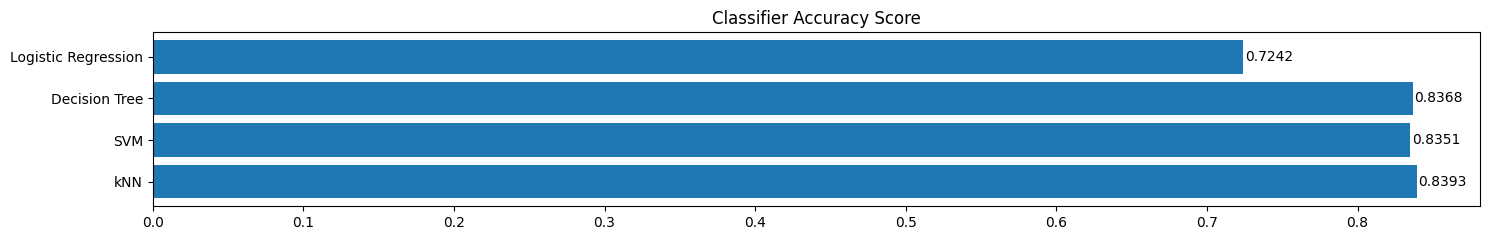

In [27]:
# 네 가지 단일 모델의 정확도를 가로 막대 차트로 비교

model_name = ['Logistic Regression', 'Decision Tree', 'SVM', 'kNN']
accuracy_scores = [lr_accuracy, tree_accuracy, svm_accuracy, knn_accuracy]

plt.figure(figsize=(15, 2.5))
bars = plt.barh(model_name[::-1], accuracy_scores[::-1])

for bar, accuracy in zip(bars, accuracy_scores[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2, f'{accuracy:.4f}', va='center')

plt.title("Classifier Accuracy Score")
plt.xlabel("")
plt.tight_layout()
plt.show()

## 앙상블 (Ensemble)

### 1. Voting

Voting은 단어 뜻 그대로 **투표를 통해 결정하는 방식**입니다. Voting은 Bagging과 투표방식이라는 점에서 유사하지만, 다음과 같은 큰 차이점이 있습니다.

- **Voting**: 서로 **다른 알고리즘** 모델들을 조합해 사용합니다.
- **Bagging**: **같은 알고리즘** 내에서 다른 샘플 조합을 사용합니다.

**Hard Voting vs Soft Voting**
| 방식 | 설명 | 예시 |
|------|------|------|
| Hard Voting | 각 모델의 예측 클래스를 다수결로 결정 | [1, 0, 1] → 1 |
| Soft Voting | 각 모델의 확률 평균으로 결정 (더 정확한 경향) | [0.7, 0.4, 0.8] → 평균 0.63 → 1 |


`VotingClassifier`

- **estimators**: 사용할 기본 분류기 리스트 (이름, 모델) 형태로 지정
- **voting**: 'hard' 또는 'soft' (기본값: 'hard')
- **weights**: 각 분류기별 가중치
- **n_jobs**: 병렬 처리 수

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html)

In [28]:
# VotingClassifier에 넣을 기본 분류기 목록
# (이름, 모델인스턴스) 튜플 형식으로 지정
# 서로 다른 알고리즘을 사용해 각 모델의 장점을 살림
models = [
    ('lr', LogisticRegression(random_state=SEED)),    # 선형 경계
    ('dt', DecisionTreeClassifier(random_state=SEED)), # 비선형 트리
    ('rf', RandomForestClassifier(random_state=SEED))  # 앙상블 트리
]

In [ ]:
# estimators는 models로, voting은 hard로 설정합니다.
# Hard Voting: 세 모델이 각각 예측한 뒤 다수결로 최종 클래스 결정
voting_clf = ****************(estimators=******, voting='****')

voting_clf.fit(X_train, y_train)
y_voting_pred = voting_clf.predict(X_test)
print(f"Voting Accuracy: {accuracy_score(y_test, y_voting_pred):.4f}")

Voting Accuracy: 0.8505


### 2. Bagging

Bootstrap + Aggregating   
1. 부트스트랩을 통해 전체 데이터셋에서 중복을 허용하여 무작위로 재표본 추출을 하고,
2. 동일한 알고리즘 모델을 사용해 각각의 샘플을 독립적으로 학습하고,
3. 모든 모델의 예측값을 결합해 최종 결과를 도출하는 방법입니다.

`RandomForestClassifier`

- **n_estimators**: 트리 개수
- **max_depth**: 트리 최대 깊이
- **max_features**: 노드 분할 시 고려할 특성 수
- **min_samples_split**: 노드 분할에 필요한 최소 샘플 수
- **bootstrap**: 부트스트랩 여부 (기본값: True)

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [ ]:
# 랜덤 포레스트 (배깅의 대표 모델)
# 부트스트랩 샘플링으로 만든 여러 결정 트리를 학습하고, 다수결로 최종 예측
# 개별 트리보다 과대적합에 강하고 안정적인 성능을 보임
# n_estimators 기본값: 100 (트리 100개 사용)
rf_clf = **********************(random_state=SEED)
rf_clf.fit(X_train, y_train)
y_rf_pred = rf_clf.predict(X_test)
print(f"Bagging (Random Forest) Accuracy: {accuracy_score(y_test, y_rf_pred):.4f}")

Bagging (Random Forest) Accuracy: 0.8514


### 3. Boosting

약한 학습기를 순차적으로 학습을 하되, 이전 학습에 대하여 잘못 예측된 데이터에 **가중치를 부여해 오차를 보완**해 나가는 방식입니다.

**장점** 
- 성능이 매우 우수합니다. (Lgbm, XGBoost 등)

**단점**
- 부스팅 알고리즘의 특성상 계속 약점(오분류/잔차)을 보완하려고 하기 때문에 **잘못된 레이블링이나 아웃라이어에 필요 이상으로 민감**할 수 있습니다.
- 순차적이기 때문에 병렬처리에 어려움이 있고, 그렇다보니 **학습 시간이 오래 걸립니다.**.

#### 3.1 AdaBoost

- 가장 초기 모델  
- 요즘 잘 안씀

`AdaBoostClassifier`

- **estimator**: 기본 약한 학습기
- **n_estimators**: 학습기 개수
- **learning_rate**: 학습률

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)

In [ ]:
# AdaBoost: 가장 초기의 부스팅 알고리즘
# 매 반복마다 이전 모델이 틀린 샘플에 더 높은 가중치를 부여해 다음 모델이 집중 학습
# 최종 예측은 각 약한 학습기(weak learner)의 가중 합산으로 결정
adaboost = ******************(random_state=SEED)
adaboost.fit(X_train, y_train)
y_ada_pred = adaboost.predict(X_test)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_ada_pred):.4f}")

AdaBoost Accuracy: 0.8230


#### 3.2 GBM

- 성능이 우수함
- 학습시간이 해도해도 너무 느림

`GradientBoostingClassifier`

- **n_estimators**: 부스팅 단계 수
- **learning_rate**: 각 단계의 기여도
- **max_depth**: 개별 트리의 최대 깊이
- **subsample**: 학습 데이터 샘플 비율
- **min_samples_split**: 노드 분할 최소 샘플 수
- **loss**: 손실 함수 ('log_loss', 'exponential')

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)

In [ ]:
# GBM(Gradient Boosting Machine): 잔차(residual)를 순차적으로 학습
# 이전 모델의 예측 오차(잔차)를 다음 트리가 학습하는 방식으로 점진적으로 개선
# 성능이 매우 우수하지만, 순차 학습 특성상 속도가 느림 (병렬 처리 불가)
gbm = **************************(random_state=SEED)
gbm.fit(X_train, y_train)
y_gbm_pred = gbm.predict(X_test)
print(f"GBM Accuracy: {accuracy_score(y_test, y_gbm_pred):.4f}")

GBM Accuracy: 0.8660


#### 3.3 XGBoost

- scikit-learn 패키지 X
- GBM보다는 빠르고 성능도 향상됨
- 그러나 여전히 학습시간이 느림
- 대신 정확도가 굉장히 높아 대회에서 사용함

`XGBClassifier`

- **n_estimators**: 부스팅 반복 횟수
- **learning_rate**: 학습률
- **max_depth**: 트리 깊이
- **subsample**: 샘플 비율
- **colsample_bytree**: 트리당 특성 샘플 비율
- **gamma**: 분할 최소 손실 감소
- **objective**: 목적 함수 ('multi:softprob', 'binary:logistic' 등)
- **eval_metric**: 평가 지표 ('mlogloss', 'logloss', 'error' 등)

[Docs](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier)

In [ ]:
# XGBoost: GBM의 속도·성능을 대폭 개선한 부스팅 라이브러리
# GBM과 달리 병렬 처리·캐시 최적화·정규화(L1/L2)를 지원해 속도와 과적합 방지 모두 개선
# 캐글(Kaggle) 등 데이터 대회에서 널리 사용됨
xgboost = xgb.*************(random_state=SEED)
xgboost.fit(X_train, y_train)
y_xgb_pred = xgboost.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_xgb_pred):.4f}")

XGBoost Accuracy: 0.8608


#### 3.4 LightGBM

- scikit-learn 패키지 X (Microsoft사 개발)
- 성능이 우수함
- 기존 부스팅 계열 알고리즘이 가지는 단점인 **느린 학습 속도를 개선**함

`LGBMClassifier`

- **n_estimators**: 트리 개수
- **learning_rate**: 학습률
- **max_depth**: 최대 깊이 (기본: -1 → 제한 없음)
- **num_leaves**: 리프 노드 수
- **subsample**: 데이터 샘플 비율
- **colsample_bytree**: 트리당 특성 샘플 비율
- **min_child_samples**: 리프 노드의 최소 샘플 수
- **objective**: 'binary', 'multiclass' 등

[Docs](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html)

In [ ]:
# LightGBM: Microsoft 개발, 기존 GBM 계열의 느린 속도를 크게 개선
# 핵심 차이: Leaf-wise 트리 성장 (기존 GBM은 Level-wise)
#   → 같은 연산량으로 손실을 더 크게 줄여 빠르고 높은 성능 달성
lgbm = lgb.**************(random_state=SEED, verbose=-1)
lgbm.fit(X_train, y_train)
y_lgbm_pred = lgbm.predict(X_test)
print(f"LightGBM Accuracy: {accuracy_score(y_test, y_lgbm_pred):.4f}")

LightGBM Accuracy: 0.8686


#### 3.5 CatBoost

`CatBoostClassifier`

- **iterations**: 부스팅 반복 횟수
- **learning_rate**: 학습률
- **depth**: 트리 깊이
- **l2_leaf_reg**: L2 정규화 계수
- **loss_function**: 손실 함수 (예: 'Logloss', 'MultiClass')
- **random_state**: 랜덤 시드
- **verbose**: 출력 제어 (0: 진행 메시지 표시하지 않음, 100: 진행률 표시)

[Docs](https://catboost.ai/en/docs/concepts/python-reference_catboostclassifier)

In [ ]:
# CatBoost: Yandex 개발, 범주형 변수를 별도 인코딩 없이 자동으로 처리하는 부스팅 모델
# 범주형 피처가 많은 데이터에서 특히 강점을 가짐
# depth=10: 트리 최대 깊이 (기본값 6보다 깊게 설정 → 더 복잡한 패턴 학습)
cb = ******************(random_state=SEED, depth=10, verbose=0)
cb.fit(X_train, y_train)
y_cb_pred = cb.predict(X_test)
print(f"CatBoost Accuracy: {accuracy_score(y_test, y_cb_pred):.4f}")

CatBoost Accuracy: 0.8600


### 4. Stacking

개별 모델이 예측한 데이터를 기반으로 **final_estimator**가 종합하여 최종 예측을 수행합니다.

**동작 원리**
1. 훈련 데이터를 k-fold로 나눠 각 base 모델을 학습
2. base 모델들이 예측한 결과를 새로운 피처로 만들어 메타 데이터셋 구성
3. 메타 모델(final_estimator)이 메타 데이터셋을 학습해 최종 예측

> 💡 성능을 극한까지 끌어올릴 때 사용하지만, 과대적합 위험이 있고 학습 시간이 매우 깁니다.

`StackingClassifier`

In [ ]:
# base_learners: 1단계에서 각자 예측값을 생성할 모델들
# 서로 다른 알고리즘을 사용해 다양한 관점의 예측값을 확보
base_learners = [
    ('lr', LogisticRegression(random_state=SEED)),
    ('dt', DecisionTreeClassifier(random_state=SEED)),
    ('rf', RandomForestClassifier(random_state=SEED))
]

stack_clf = ******************(
    estimators=base_learners,
    final_estimator=LogisticRegression(random_state=SEED),  # 2단계: 메타 모델
    cv=5  # 5-fold 교차검증으로 메타 데이터셋 생성 (데이터 누수 방지)
)

stack_clf.fit(X_train, y_train)
y_stk_pred = stack_clf.predict(X_test)
print(f"Stacking Accuracy: {accuracy_score(y_test, y_stk_pred):.4f}")

Stacking Accuracy: 0.8514


## 앙상블 모델을 정리하며

1. 앙상블은 대체적으로 단일 모델 대비 성능이 좋습니다.
2. 앙상블을 앙상블하는 기법인 Stacking도 참고해볼만 합니다.
3. 앙상블 모델은 적절한 **Hyperparameter 튜닝**이 중요합니다.
4. 앙상블 모델은 대체적으로 학습시간이 더 오래 걸립니다.
5. 따라서, 모델 튜닝을 하는 데에 걸리는 시간도 오래 소요됩니다.

수고하셨습니다~~